Relative symbol frequency plots. Only for Split datasets without length cost. Overall, 11 plots: one for each run of each Split dataset.

Additionally, average plots across runs for each Split dataset, focusing on frequencies of symbols encoding highly discriminative attribute vs. all other symbols. EOS Symbol "0" is excluded from consideration.

In [29]:
from utils.load_results import *
from utils.plot_helpers import *
from utils.analysis_from_interaction import error_analysis
from collections import Counter
from utils.analysis_from_interaction import *
import itertools
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('default')
import random
from seaborn.algorithms import bootstrap
import pickle
from utils.analysis_from_interaction import *
from egg.core.language_analysis import Disent
from language_analysis_local import TopographicSimilarityConceptLevel, encode_target_concepts_for_topsim
import os
import numpy as np
from matplotlib.ticker import PercentFormatter

In [30]:
# (potentially) useful functions copied from qualitative_utils.py from zero-shot repository
# https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/qualitative_utils.py
def objects_to_concepts(sender_input):
    """reconstruct concepts from objects in interaction"""
    n_targets = int(sender_input.shape[1]/2)
    # get target objects and fixed vectors to re-construct concepts
    target_objects = sender_input[:, :n_targets]
    target_objects = k_hot_to_attributes(target_objects, n_values[i])
    # concepts are defined by a list of target objects (here one sampled target object) and a fixed vector
    (objects, fixed) = retrieve_concepts_sampling(target_objects, all_targets=True)
    concepts = list(zip(objects, fixed))
    return concepts

# modified to trim the messages (delete the first 0 and everything that comes after)
# using trim_tensor from analysis_from_interaction.py
def retrieve_messages(interaction, is_gumbel=True):
    """retrieve messages from interaction"""
    if is_gumbel:
        messages = interaction.message.argmax(dim=-1)
        messages = [trim_tensor(message) for message in messages]
        messages = [msg.tolist() for msg in messages]
    else:
        messages = interaction.message.argmax(dim=2)
        messages = [trim_tensor(message) for message in messages]
        messages = [msg.tolist() for msg in messages]
    return messages


def count_symbols(messages):
    """counts symbols in messages"""
    all_symbols = [symbol for message in messages for symbol in message]
    symbol_counts = Counter(all_symbols)
    return symbol_counts

def get_unique_message_set(messages):
    """returns unique messages as a set ready for set operations"""
    return set(tuple(message) for message in messages)

def get_unique_concept_set(concepts):
    """returns unique concepts"""
    concept_tuples = []
    for objects, fixed in concepts:
        tuple_objects = []
        for object in objects:
            tuple_objects.append(tuple(object))
        tuple_objects = tuple(tuple_objects)
        tuple_concept = (tuple_objects, tuple(fixed))
        concept_tuples.append(tuple_concept)
    tuple(concept_tuples)
    unique_concepts = set(concept_tuples)
    return unique_concepts

In [31]:
# a function to calculate relative symbol frequencies to plot them later
# count of each symbol divided by total count of all symbols
def calculate_relative_frequencies(symbol_counts: Counter):
    total_symbols = sum(symbol_counts.values())
    if total_symbols == 0:
        return {} # return an empty dictionary if there are no symbols

    relative_frequencies = {
        symbol: count / total_symbols for symbol, count in symbol_counts.items()
    }
    return relative_frequencies

In [32]:
# a function to plot relative symbol frequencies
# generates a combined bar plot for symbol frequencies from train, val, and test sets
def plot_combined_symbol_frequencies(
    symbol_counts_train,
    symbol_counts_val,
    symbol_counts_test,
    title,
    figsize=(12, 7),
    title_fs=24,
    axislabel_fs=20,
    tick_fs=18,
    legend_fs=18,
    rotate_x=0,
    savepath=None
):
    # convert Counters to DataFrames
    df_train = (pd.DataFrame.from_dict(symbol_counts_train, orient='index', columns=['Frequency'])
                  .reset_index().rename(columns={'index': 'Symbol'}))
    df_train['Set'] = 'Training'

    df_val = (pd.DataFrame.from_dict(symbol_counts_val, orient='index', columns=['Frequency'])
                .reset_index().rename(columns={'index': 'Symbol'}))
    df_val['Set'] = 'Validation'

    df_test = (pd.DataFrame.from_dict(symbol_counts_test, orient='index', columns=['Frequency'])
                 .reset_index().rename(columns={'index': 'Symbol'}))
    df_test['Set'] = 'Testing'

    # combine & ensure proper types
    df_combined = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df_combined['Symbol'] = df_combined['Symbol'].astype(int)

    # sort symbols by training frequency (descending)
    symbol_order = (df_train.sort_values('Frequency', ascending=False)['Symbol'].tolist())

    # plot
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    sns.barplot(
        x='Symbol', y='Frequency', hue='Set',
        data=df_combined, palette='viridis',
        order=symbol_order, ax=ax
    )

    # title & labels (scaled up so that it's visible in LaTeX)
    ax.set_title(title, fontsize=title_fs, pad=12)
    ax.set_xlabel('Symbol', fontsize=axislabel_fs)          
    ax.set_ylabel('Relative Frequency', fontsize=axislabel_fs)

    # bigger tick labels on both axes (so that it's visible in LaTeX)
    ax.tick_params(axis='x', labelsize=tick_fs)
    ax.tick_params(axis='y', labelsize=tick_fs)
    if rotate_x:
        for tick in ax.get_xticklabels():
            tick.set_rotation(rotate_x)
            tick.set_horizontalalignment('center')

    # legend (scaled up)
    leg = ax.legend(title='Data Set', fontsize=legend_fs, title_fontsize=legend_fs, frameon=False)

    # tight layout & optional save
    plt.tight_layout()
    if savepath is not None:
        ext = os.path.splitext(savepath)[1].lower()
        if ext in {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}:
            plt.savefig(savepath, dpi=600, bbox_inches='tight')
        else:
            plt.savefig(savepath, bbox_inches='tight')
    plt.show()

In [33]:
# a function to calculate average relative frequencies for symbols associated with HDA vs. other symbols;
# (HDA - highly discriminative attribute)
# for each run, symbols associated with HDA are provided as a list (manually taken from analysis of symbol-attribute MI scores, 
# see split_analysis_mi_scores.ipynb);
# symbol 0 is excluded from consideration
def average_freqs_for_groups(relative_freqs: dict, hda_symbols: list):
    """
    Given a dict {symbol: rel_freq} for one split in one run,
    returns (hda_avg, other_avg) with symbol 0 excluded.
    - HDA avg: mean over the provided hda_symbols, counting 0.0 if a symbol wasn't used.
    - Other avg: mean over all symbols that were USED (freq>0), excluding symbol {0} and HDA symbols.
    """
    hda_set = set(hda_symbols)
    # Exclude symbol 0 from consideration everywhere
    rel = {s: f for s, f in relative_freqs.items() if s != 0}

    # HDA average: divide by the number of HDA symbols for that run
    hda_vals = [rel.get(s, 0.0) for s in hda_symbols]
    hda_avg = float(np.mean(hda_vals)) if len(hda_vals) > 0 else 0.0

    # other average: only symbols that were actually used (freq > 0), excluding symbols associated with HDA
    other_vals = [f for s, f in rel.items() if (s not in hda_set) and (f > 0.0)]
    other_avg = float(np.mean(other_vals)) if len(other_vals) > 0 else 0.0

    return hda_avg, other_avg

# a function to plot the average relative frequencies of symbols associated with HDA vs other symbols (across runs)
def plot_hda_vs_other_across_runs(avg_across_runs, title, savepath=None,
                                  figsize=(10, 7),
                                  title_fs=24, axislabel_fs=20, tick_fs=18, legend_fs=18,
                                  y_min=0.0, y_max=0.25, strict=False):
    df = pd.DataFrame([
        {'Set': 'Training',   'Group': 'HDA symbols',   'AvgRelFreq': avg_across_runs['train']['hda']},
        {'Set': 'Training',   'Group': 'Other symbols', 'AvgRelFreq': avg_across_runs['train']['other']},
        {'Set': 'Validation', 'Group': 'HDA symbols',   'AvgRelFreq': avg_across_runs['val']['hda']},
        {'Set': 'Validation', 'Group': 'Other symbols', 'AvgRelFreq': avg_across_runs['val']['other']},
        {'Set': 'Testing',    'Group': 'HDA symbols',   'AvgRelFreq': avg_across_runs['test']['hda']},
        {'Set': 'Testing',    'Group': 'Other symbols', 'AvgRelFreq': avg_across_runs['test']['other']},
    ])

    plt.figure(figsize=figsize, constrained_layout=True)
    ax = sns.barplot(data=df, x='Set', y='AvgRelFreq', hue='Group')

    # title & labels
    ax.set_title(title, fontsize=title_fs, pad=14)
    ax.set_ylabel('Average Relative Frequency', fontsize=axislabel_fs)

    # remove x-axis title entirely (is self-explanatory)
    ax.set_xlabel(None)
    ax.xaxis.label.set_visible(False)

    # bigger tick labels
    ax.tick_params(axis='x', labelsize=tick_fs)
    ax.tick_params(axis='y', labelsize=tick_fs)

    # legend outside to the right
    ax.legend(title=None, fontsize=legend_fs, frameon=False,
                    loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
    # shared y-scale for all plots (set to 0.25)
    data_max = df['AvgRelFreq'].max()                 
    if strict:                                        
        ax.set_ylim(y_min, y_max)                    
    else:                                             
        # use the shared cap unless data requires more headroom              
        ax.set_ylim(y_min, max(y_max, data_max * 1.05))                     

    # tight layout & optional save
    plt.tight_layout()
    if savepath is not None:
        ext = os.path.splitext(savepath)[1].lower()
        if ext in {'.png', '.jpg', '.jpeg', '.tif', '.tiff'}:
            plt.savefig(savepath, dpi=600, bbox_inches='tight')
        else:
            plt.savefig(savepath, bbox_inches='tight')
    plt.show()

D(3,3) Split, No length cost, Vocab size 13,

 5 runs

HDA - highly discriminative attribute

HDA Indices in each run: 1, 0, 2, 1, 0

In [34]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

(3,3)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\4003767917.py:61: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


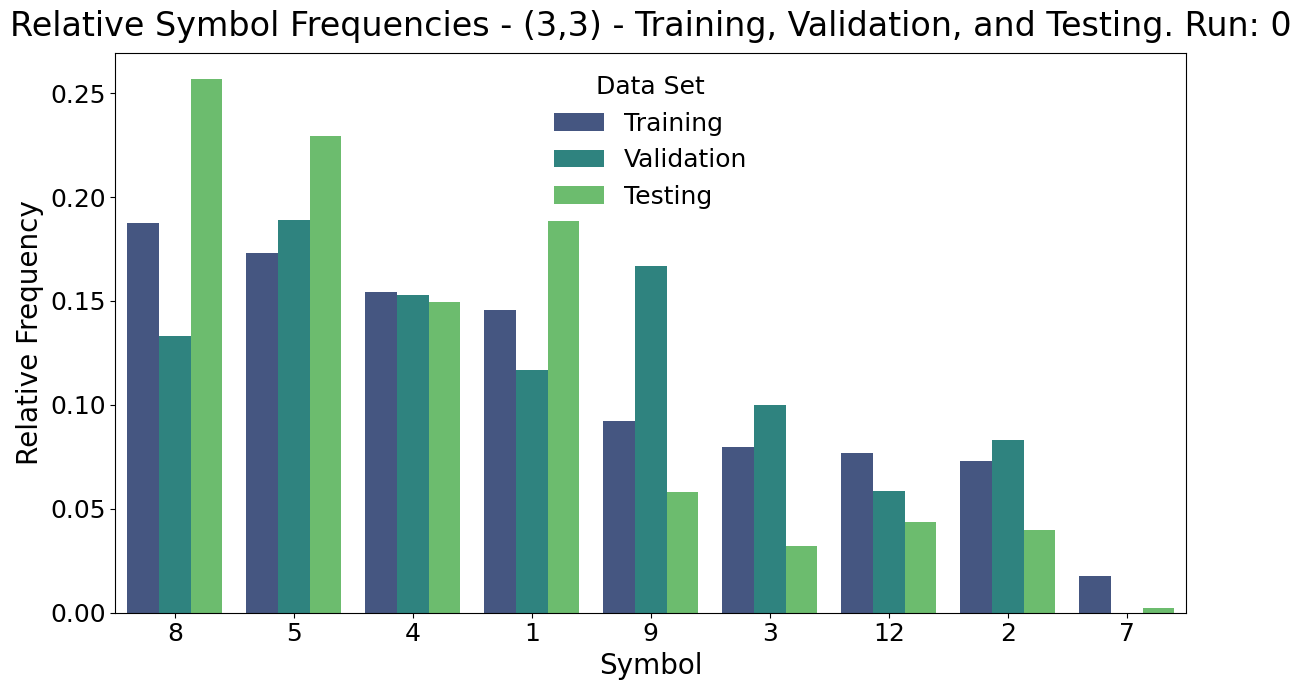

C:\Users\metel\AppData\Local\Temp\ipykernel_1924\4003767917.py:61: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


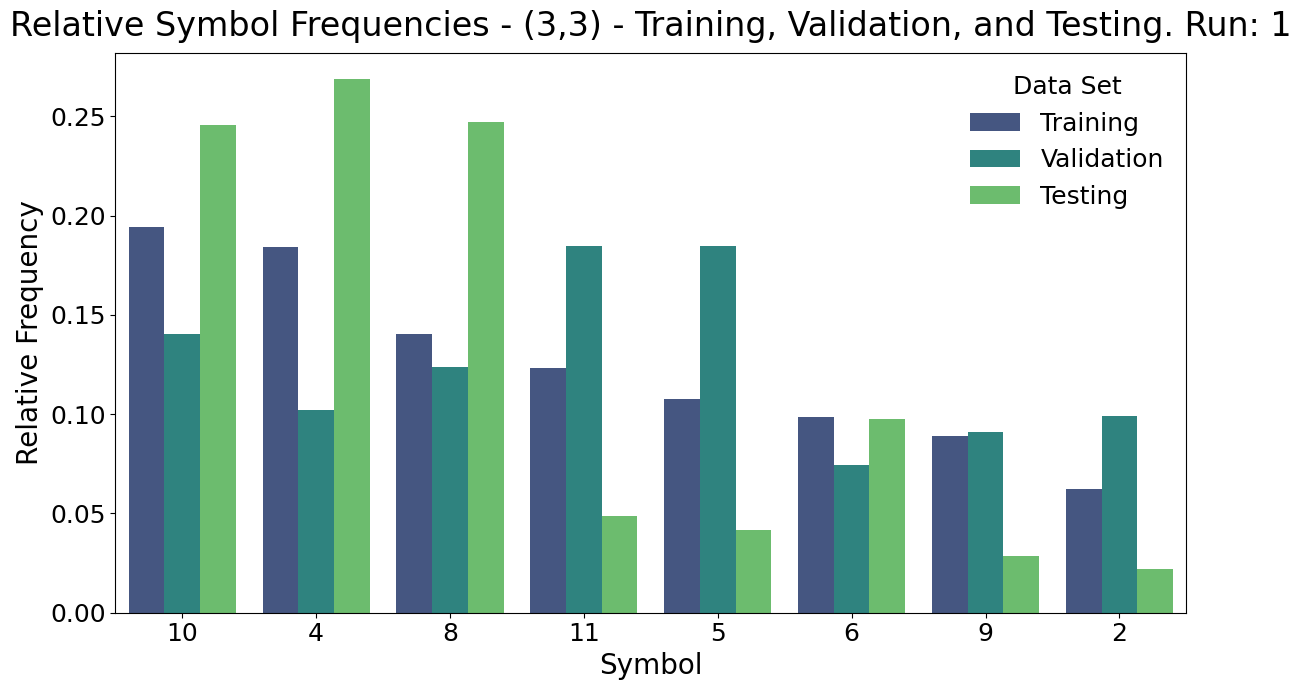

C:\Users\metel\AppData\Local\Temp\ipykernel_1924\4003767917.py:61: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


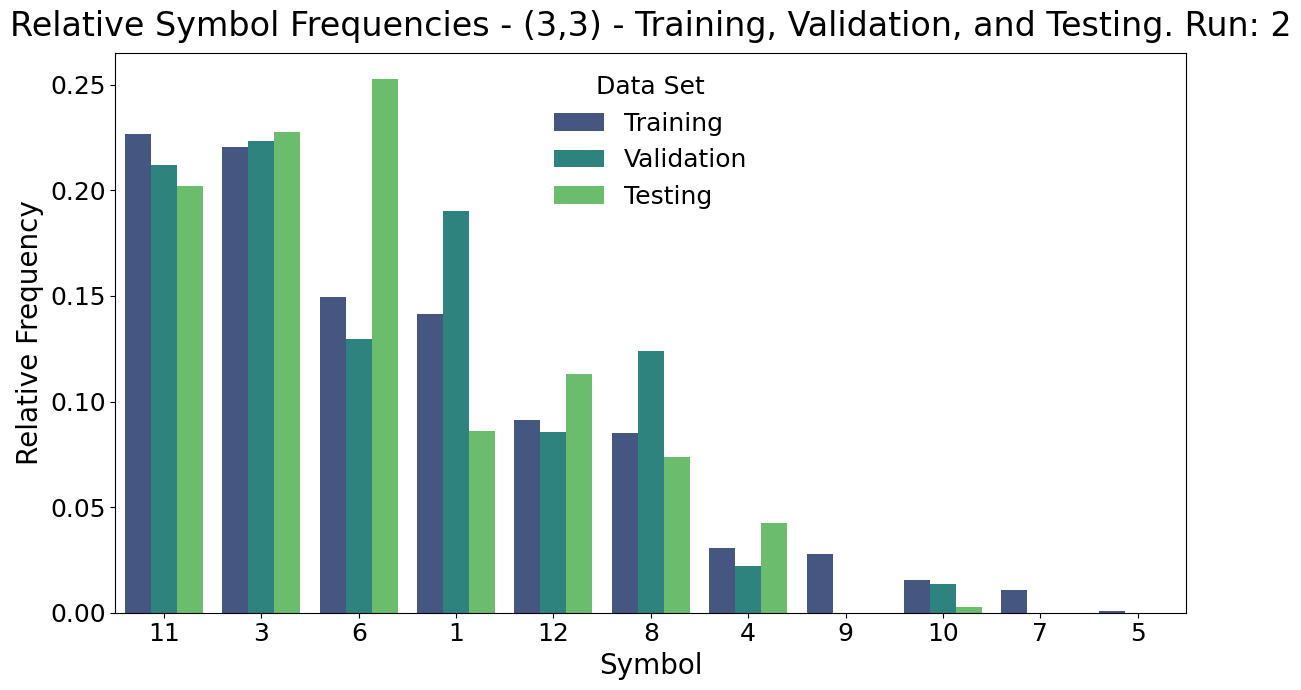

C:\Users\metel\AppData\Local\Temp\ipykernel_1924\4003767917.py:61: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


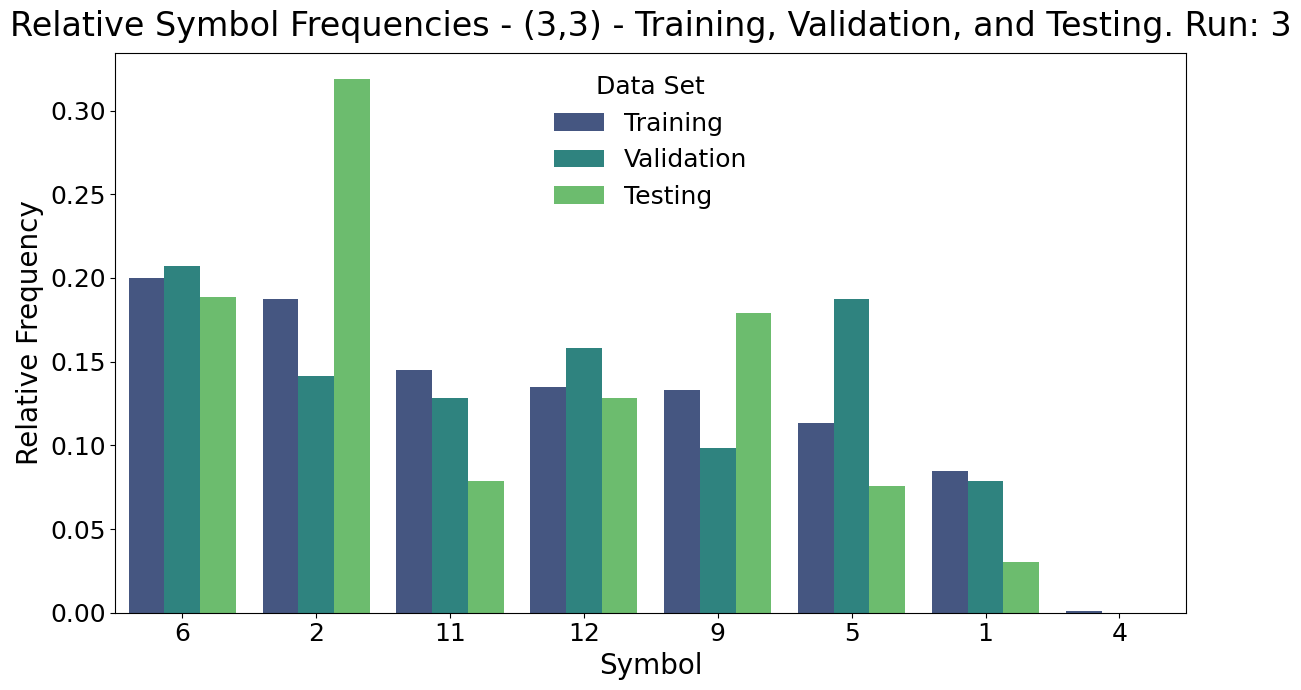

C:\Users\metel\AppData\Local\Temp\ipykernel_1924\4003767917.py:61: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


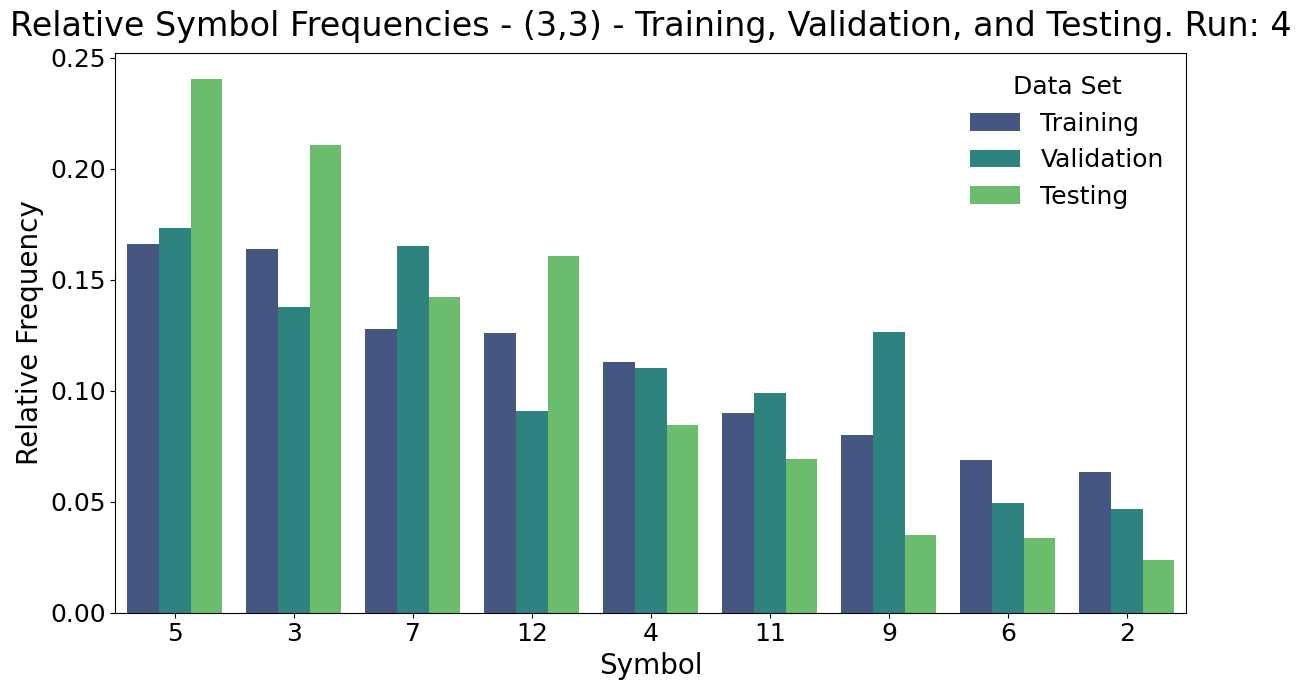

In [35]:
att_per_run = [1, 0, 2, 1, 0] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        #print("Frequencies of the used symbols in training:")
        #display(symbol_counts_train)
        #print("Frequencies of the used symbols in validation:")
        #display(symbol_counts_val)
        #print("Frequencies of the used symbols in testing:")
        #display(symbol_counts_test)
        plot_combined_symbol_frequencies(calculate_relative_frequencies(symbol_counts_train), calculate_relative_frequencies(symbol_counts_val), calculate_relative_frequencies(symbol_counts_test), 'Relative Symbol Frequencies - ' + str(d) + ' - Training, Validation, and Testing. Run: ' + str(run))

(3,3)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\2993232450.py:68: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


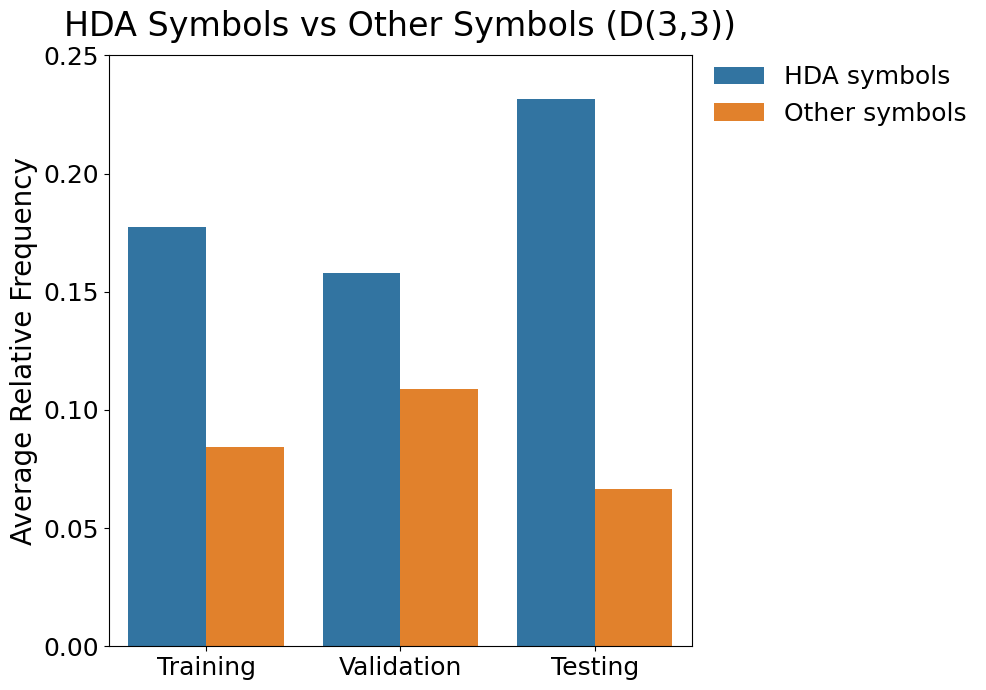

In [ ]:
hda_symbols_by_run = { # symbols associated with highly discriminative attribute, per run
    0: [8, 5, 1],
    1: [10, 4, 8],
    2: [3, 11, 6],
    3: [6, 2], # here, the third symbol is not considered, as it is 0 (see table with symbol-attribute MI scores for D(3,3), run 3)
    4: [7, 5, 3],
}
acc = {
    'train': {'hda': [], 'other': []},
    'val':   {'hda': [], 'other': []},
    'test':  {'hda': [], 'other': []},
}
att_per_run = [1, 0, 2, 1, 0] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        hda_syms = hda_symbols_by_run[run]

        rel_train = calculate_relative_frequencies(symbol_counts_train)
        rel_val   = calculate_relative_frequencies(symbol_counts_val)
        rel_test  = calculate_relative_frequencies(symbol_counts_test)

        hda_tr, other_tr = average_freqs_for_groups(rel_train, hda_syms)
        hda_va, other_va = average_freqs_for_groups(rel_val,   hda_syms)
        hda_te, other_te = average_freqs_for_groups(rel_test,  hda_syms)

        acc['train']['hda'].append(hda_tr)
        acc['train']['other'].append(other_tr)
        acc['val']['hda'].append(hda_va)
        acc['val']['other'].append(other_va)
        acc['test']['hda'].append(hda_te)
        acc['test']['other'].append(other_te)
    # average across runs for this dataset
    avg_across_runs = {
        'train': {'hda': float(np.mean(acc['train']['hda'])) if acc['train']['hda'] else 0.0,
                  'other': float(np.mean(acc['train']['other'])) if acc['train']['other'] else 0.0},
        'val':   {'hda': float(np.mean(acc['val']['hda'])) if acc['val']['hda'] else 0.0,
                  'other': float(np.mean(acc['val']['other'])) if acc['val']['other'] else 0.0},
        'test':  {'hda': float(np.mean(acc['test']['hda'])) if acc['test']['hda'] else 0.0,
                  'other': float(np.mean(acc['test']['other'])) if acc['test']['other'] else 0.0},
    }
    save_to = os.path.join(paths[0], setting, f'{d}_avg_HDA_vs_Other_across_runs.png')
    plot_hda_vs_other_across_runs(
        avg_across_runs,
        title=f'HDA Symbols vs Other Symbols (D{d})',
        savepath=save_to
    )

D(3,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 0, 0

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

(3,4)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\3841557023.py:60: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


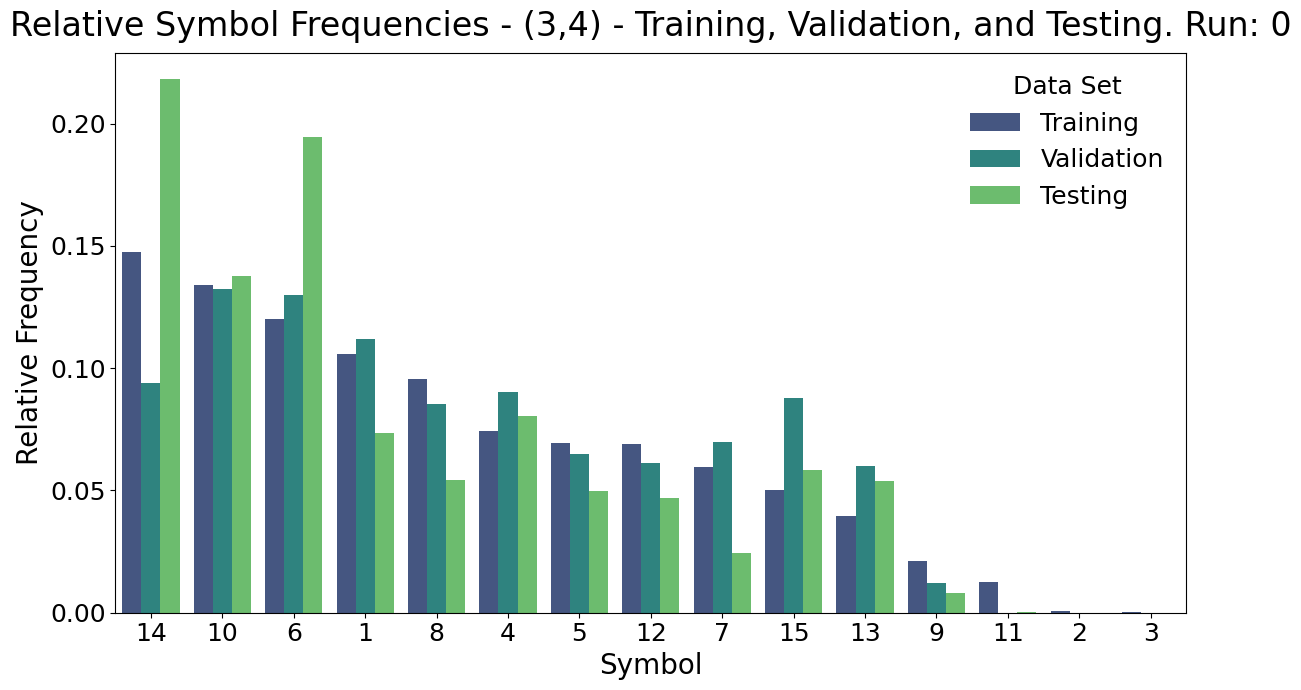

C:\Users\metel\AppData\Local\Temp\ipykernel_1924\3841557023.py:60: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


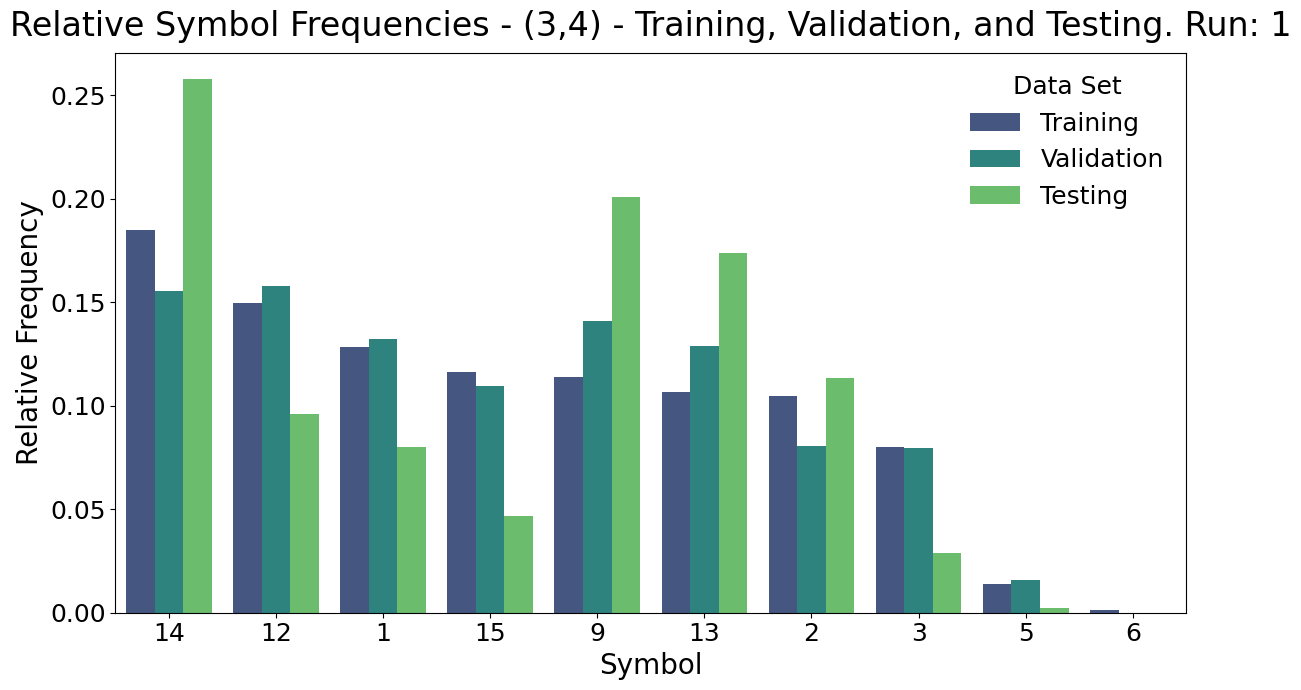

In [24]:
att_per_run = [0, 0] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        #print("Frequencies of the used symbols in training:")
        #display(symbol_counts_train)
        #print("Frequencies of the used symbols in validation:")
        #display(symbol_counts_val)
        #print("Frequencies of the used symbols in testing:")
        #display(symbol_counts_test)
        with plt.rc_context({'legend.loc': 'upper right'}):
            plot_combined_symbol_frequencies(
                calculate_relative_frequencies(symbol_counts_train),
                calculate_relative_frequencies(symbol_counts_val),
                calculate_relative_frequencies(symbol_counts_test),
                f'Relative Symbol Frequencies - {d} - Training, Validation, and Testing. Run: {run}'
            )
        #plot_combined_symbol_frequencies(calculate_relative_frequencies(symbol_counts_train), calculate_relative_frequencies(symbol_counts_val), calculate_relative_frequencies(symbol_counts_test), 'Relative Symbol Frequencies - ' + str(d) + ' - Training, Validation, and Testing. Run: ' + str(run))

(3,4)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\1806997671.py:62: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


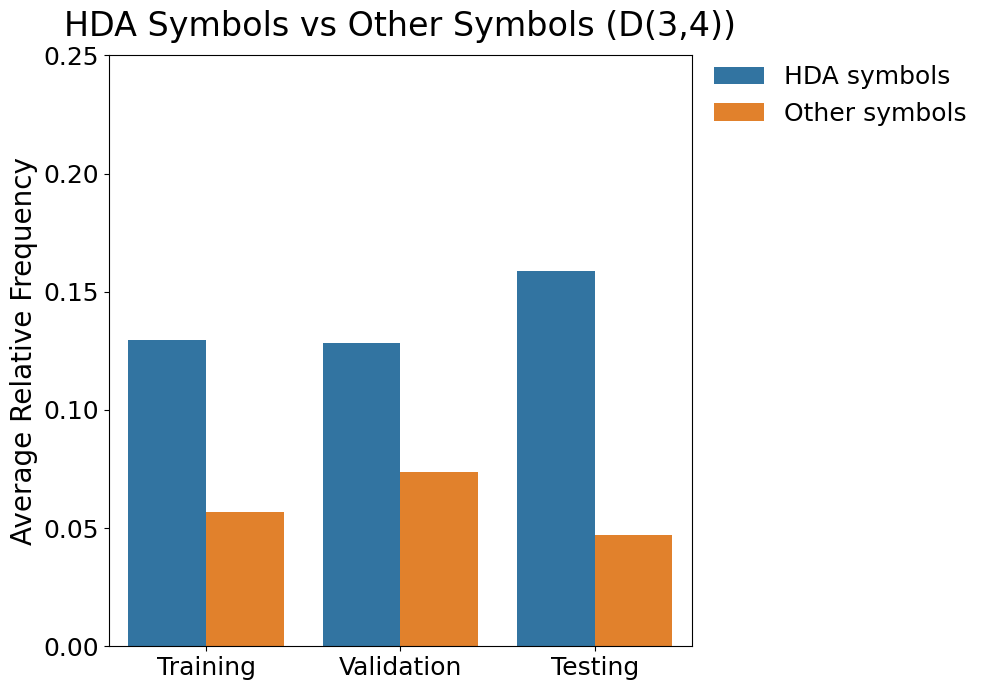

In [ ]:
hda_symbols_by_run = { # symbols associated with highly discriminative attribute, per run
    0: [14, 10, 6, 8, 1],
    1: [13, 9, 12, 14],
}

acc = {
    'train': {'hda': [], 'other': []},
    'val':   {'hda': [], 'other': []},
    'test':  {'hda': [], 'other': []},
}
att_per_run = [0, 0] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        #n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        hda_syms = hda_symbols_by_run[run]

        rel_train = calculate_relative_frequencies(symbol_counts_train)
        rel_val   = calculate_relative_frequencies(symbol_counts_val)
        rel_test  = calculate_relative_frequencies(symbol_counts_test)

        hda_tr, other_tr = average_freqs_for_groups(rel_train, hda_syms)
        hda_va, other_va = average_freqs_for_groups(rel_val,   hda_syms)
        hda_te, other_te = average_freqs_for_groups(rel_test,  hda_syms)

        acc['train']['hda'].append(hda_tr)
        acc['train']['other'].append(other_tr)
        acc['val']['hda'].append(hda_va)
        acc['val']['other'].append(other_va)
        acc['test']['hda'].append(hda_te)
        acc['test']['other'].append(other_te)
    # average across runs for this dataset and plot once ---
    avg_across_runs = {
        'train': {'hda': float(np.mean(acc['train']['hda'])) if acc['train']['hda'] else 0.0,
                  'other': float(np.mean(acc['train']['other'])) if acc['train']['other'] else 0.0},
        'val':   {'hda': float(np.mean(acc['val']['hda'])) if acc['val']['hda'] else 0.0,
                  'other': float(np.mean(acc['val']['other'])) if acc['val']['other'] else 0.0},
        'test':  {'hda': float(np.mean(acc['test']['hda'])) if acc['test']['hda'] else 0.0,
                  'other': float(np.mean(acc['test']['other'])) if acc['test']['other'] else 0.0},
    }

    save_to = os.path.join(paths[0], setting, f'{d}_avg_HDA_vs_Other_across_runs.png')
    plot_hda_vs_other_across_runs(
        avg_across_runs,
        title=f'HDA Symbols vs Other Symbols (D{d})',
        savepath=save_to
    )

    # (Optional) persist the raw numbers for later
    #with open(os.path.join(paths[0], setting, f'{d}_avg_HDA_vs_Other_across_runs.pkl'), 'wb') as f:
      #  pickle.dump(avg_across_runs, f)

D(4,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 3, 2

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

(4,4)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\3841557023.py:60: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


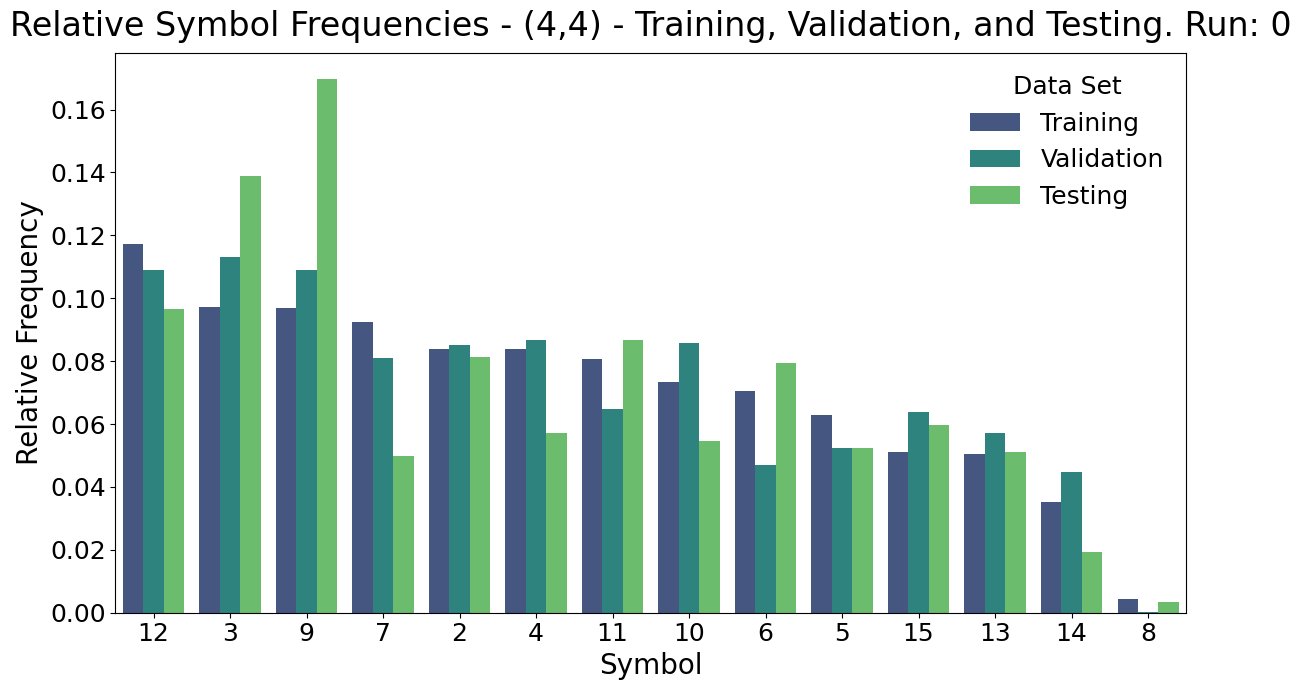

C:\Users\metel\AppData\Local\Temp\ipykernel_1924\3841557023.py:60: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


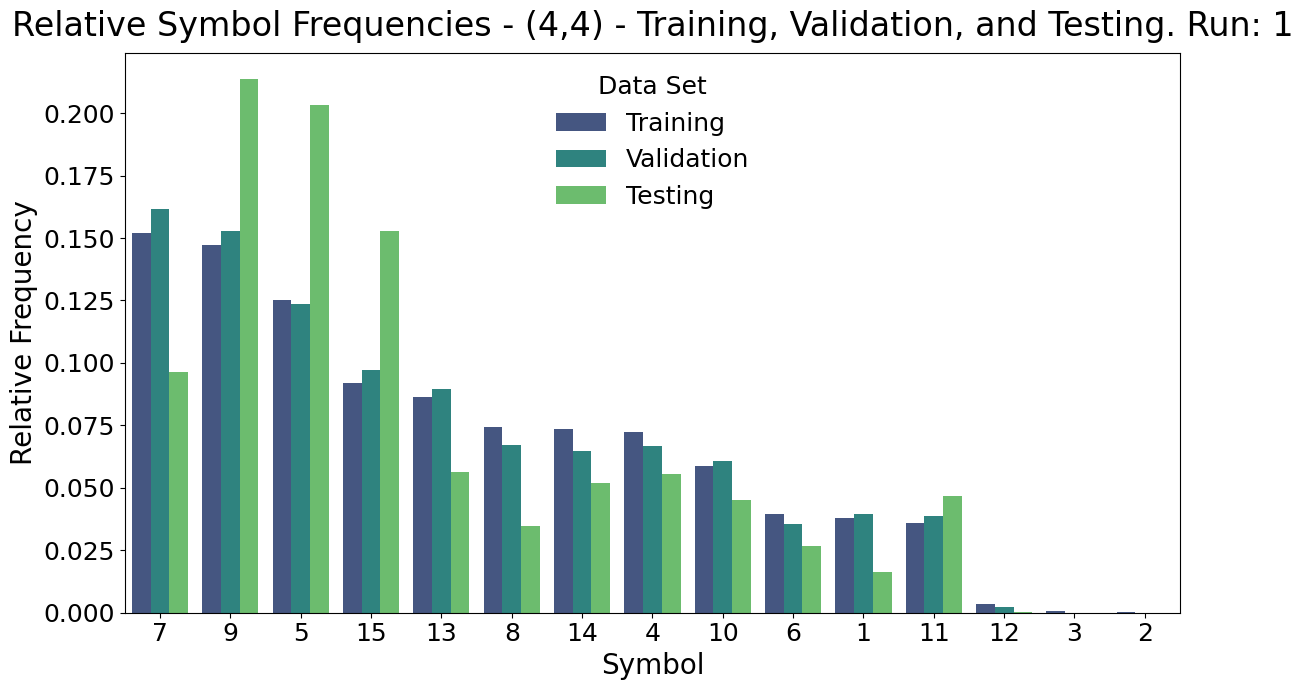

In [16]:
att_per_run = [3, 2] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        #print("Frequencies of the used symbols in training:")
        #display(symbol_counts_train)
        #print("Frequencies of the used symbols in validation:")
        #display(symbol_counts_val)
        #print("Frequencies of the used symbols in testing:")
        #display(symbol_counts_test)
        plot_combined_symbol_frequencies(calculate_relative_frequencies(symbol_counts_train), calculate_relative_frequencies(symbol_counts_val), calculate_relative_frequencies(symbol_counts_test), 'Relative Symbol Frequencies - ' + str(d) + ' - Training, Validation, and Testing. Run: ' + str(run))

(4,4)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\1806997671.py:62: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


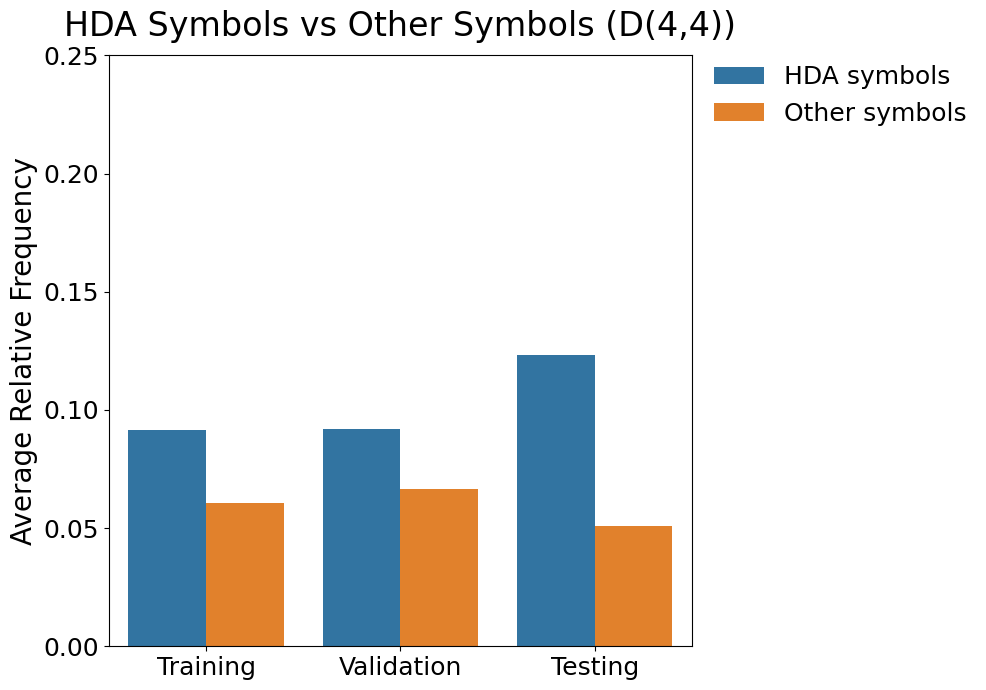

In [ ]:
hda_symbols_by_run = { # symbols associated with highly discriminative attribute, per run
    0: [2, 9, 3, 6],
    1: [9, 11, 5, 14],
}

acc = {
    'train': {'hda': [], 'other': []},
    'val':   {'hda': [], 'other': []},
    'test':  {'hda': [], 'other': []},
}
att_per_run = [3, 2] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        #n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        hda_syms = hda_symbols_by_run[run]

        rel_train = calculate_relative_frequencies(symbol_counts_train)
        rel_val   = calculate_relative_frequencies(symbol_counts_val)
        rel_test  = calculate_relative_frequencies(symbol_counts_test)

        hda_tr, other_tr = average_freqs_for_groups(rel_train, hda_syms)
        hda_va, other_va = average_freqs_for_groups(rel_val,   hda_syms)
        hda_te, other_te = average_freqs_for_groups(rel_test,  hda_syms)

        acc['train']['hda'].append(hda_tr)
        acc['train']['other'].append(other_tr)
        acc['val']['hda'].append(hda_va)
        acc['val']['other'].append(other_va)
        acc['test']['hda'].append(hda_te)
        acc['test']['other'].append(other_te)
    # average across runs for this dataset and plot once ---
    avg_across_runs = {
        'train': {'hda': float(np.mean(acc['train']['hda'])) if acc['train']['hda'] else 0.0,
                  'other': float(np.mean(acc['train']['other'])) if acc['train']['other'] else 0.0},
        'val':   {'hda': float(np.mean(acc['val']['hda'])) if acc['val']['hda'] else 0.0,
                  'other': float(np.mean(acc['val']['other'])) if acc['val']['other'] else 0.0},
        'test':  {'hda': float(np.mean(acc['test']['hda'])) if acc['test']['hda'] else 0.0,
                  'other': float(np.mean(acc['test']['other'])) if acc['test']['other'] else 0.0},
    }

    save_to = os.path.join(paths[0], setting, f'{d}_avg_HDA_vs_Other_across_runs.png')
    plot_hda_vs_other_across_runs(
        avg_across_runs,
        title=f'HDA Symbols vs Other Symbols (D{d})',
        savepath=save_to
    )

    # (Optional) persist the raw numbers for later
    #with open(os.path.join(paths[0], setting, f'{d}_avg_HDA_vs_Other_across_runs.pkl'), 'wb') as f:
      #  pickle.dump(avg_across_runs, f)

D(3,8) Split, No Length cost, vocab 28

2 runs

HDA indices in each run: 2, 1

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

(3,8)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\3841557023.py:60: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


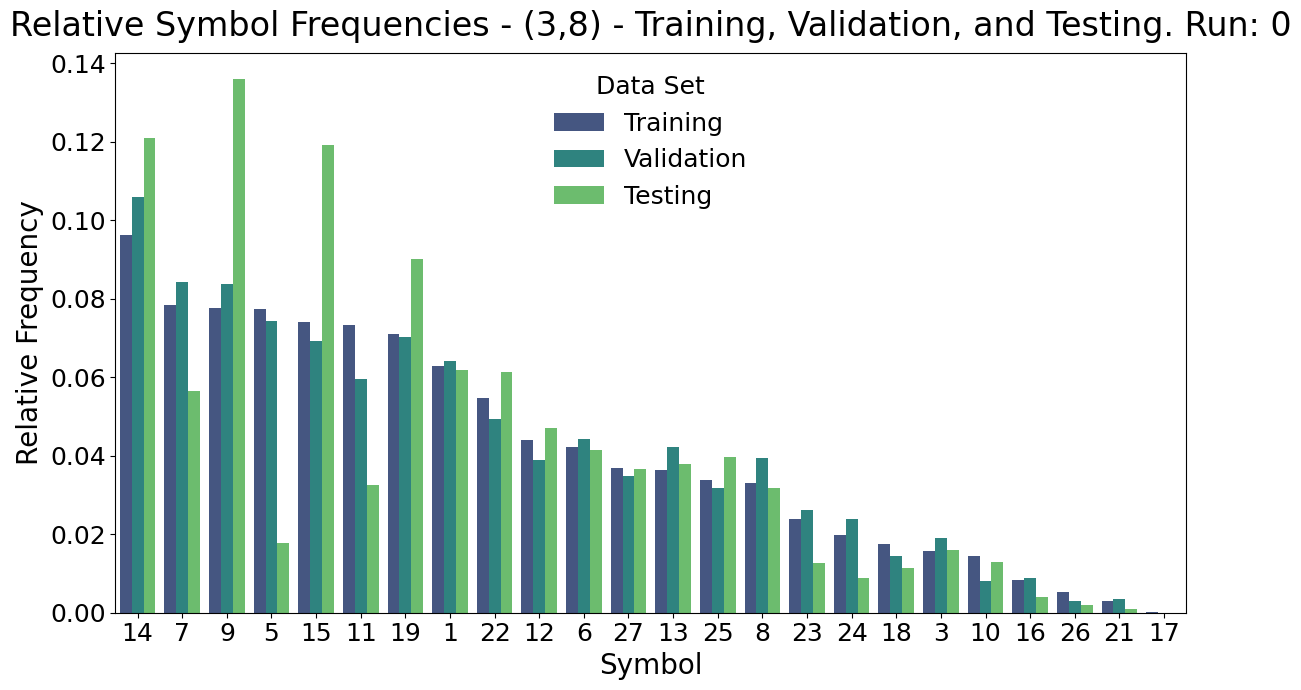

C:\Users\metel\AppData\Local\Temp\ipykernel_1924\3841557023.py:60: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


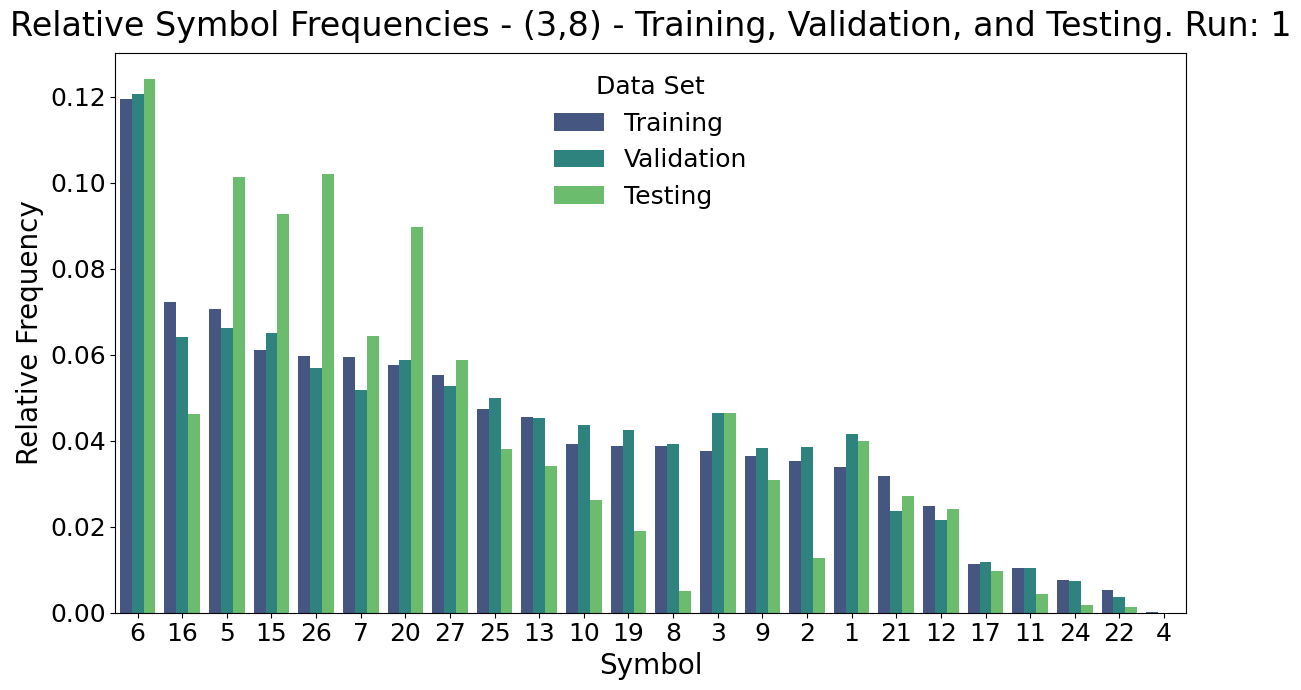

In [20]:
att_per_run = [2, 1] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        #print("Frequencies of the used symbols in training:")
        #display(symbol_counts_train)
        #print("Frequencies of the used symbols in validation:")
        #display(symbol_counts_val)
        #print("Frequencies of the used symbols in testing:")
        #display(symbol_counts_test)
        plot_combined_symbol_frequencies(calculate_relative_frequencies(symbol_counts_train), calculate_relative_frequencies(symbol_counts_val), calculate_relative_frequencies(symbol_counts_test), 'Relative Symbol Frequencies - ' + str(d) + ' - Training, Validation, and Testing. Run: ' + str(run))

(3,8)


C:\Users\metel\AppData\Local\Temp\ipykernel_1924\1806997671.py:62: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


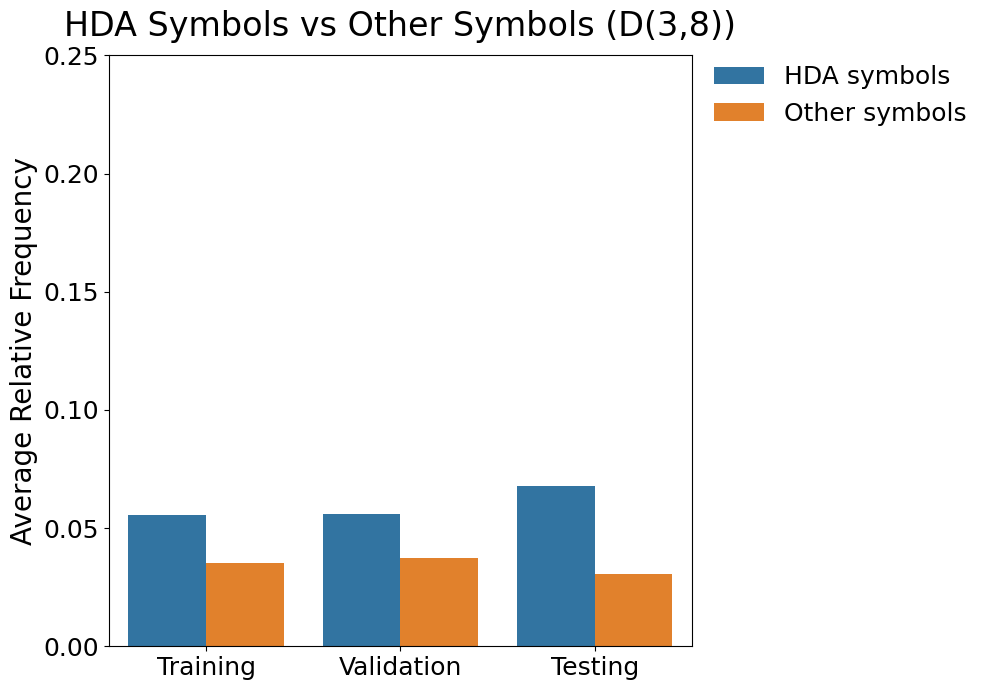

In [ ]:
hda_symbols_by_run = { # symbols associated with highly discriminative attribute, per run
    0: [7, 25, 8, 14, 9, 12, 27],
    1: [21, 26, 13, 15, 25, 20, 5, 7],
}

acc = {
    'train': {'hda': [], 'other': []},
    'val':   {'hda': [], 'other': []},
    'test':  {'hda': [], 'other': []},
}
att_per_run = [2, 1] # indices of highly discriminative attributes per run

for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        #n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

        messages_train = filter_messages(interaction_train, messages_train, att)
        messages_val = filter_messages(interaction_val, messages_val, att)
        messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        hda_syms = hda_symbols_by_run[run]

        rel_train = calculate_relative_frequencies(symbol_counts_train)
        rel_val   = calculate_relative_frequencies(symbol_counts_val)
        rel_test  = calculate_relative_frequencies(symbol_counts_test)

        hda_tr, other_tr = average_freqs_for_groups(rel_train, hda_syms)
        hda_va, other_va = average_freqs_for_groups(rel_val,   hda_syms)
        hda_te, other_te = average_freqs_for_groups(rel_test,  hda_syms)

        acc['train']['hda'].append(hda_tr)
        acc['train']['other'].append(other_tr)
        acc['val']['hda'].append(hda_va)
        acc['val']['other'].append(other_va)
        acc['test']['hda'].append(hda_te)
        acc['test']['other'].append(other_te)
    # average across runs for this dataset and plot once ---
    avg_across_runs = {
        'train': {'hda': float(np.mean(acc['train']['hda'])) if acc['train']['hda'] else 0.0,
                  'other': float(np.mean(acc['train']['other'])) if acc['train']['other'] else 0.0},
        'val':   {'hda': float(np.mean(acc['val']['hda'])) if acc['val']['hda'] else 0.0,
                  'other': float(np.mean(acc['val']['other'])) if acc['val']['other'] else 0.0},
        'test':  {'hda': float(np.mean(acc['test']['hda'])) if acc['test']['hda'] else 0.0,
                  'other': float(np.mean(acc['test']['other'])) if acc['test']['other'] else 0.0},
    }

    save_to = os.path.join(paths[0], setting, f'{d}_avg_HDA_vs_Other_across_runs.png')
    plot_hda_vs_other_across_runs(
        avg_across_runs,
        title=f'HDA Symbols vs Other Symbols (D{d})',
        savepath=save_to
    )

    # (Optional) persist the raw numbers for later
    #with open(os.path.join(paths[0], setting, f'{d}_avg_HDA_vs_Other_across_runs.pkl'), 'wb') as f:
      #  pickle.dump(avg_across_runs, f)

No-Split datasets settings (in case plotting their relative symbol frequencies will also be required)

D(3,3) No split (shared_context), No Length cost, vocab 13

5 runs

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [ ]:
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)
        
        concepts_train = objects_to_concepts(interaction_train.sender_input)
        concepts_val = objects_to_concepts(interaction_val.sender_input)
        concepts_test = objects_to_concepts(interaction_test.sender_input)
        
        # retrieving trimmed messages (deleting the first EOS and everything that comes after)
        messages_train = retrieve_messages(interaction_train)
        messages_val = retrieve_messages(interaction_val)
        messages_test = retrieve_messages(interaction_test, is_gumbel=False)

        att=att_per_run[run]  # index of the highly discriminative attribute for this run

        # filtering messages, so that
        # the plot looks only at the messages that refer to targets where attribute with index att is fixed
        n_targets = int(interaction_train.sender_input.shape[1] / 2)
        def filter_messages(interaction, messages, att):
            target_objects = interaction.sender_input[:, :n_targets]
            target_objects = k_hot_to_attributes(target_objects, n_values[i])
            objects, fixed = retrieve_concepts_sampling(target_objects, all_targets=True)
            fixed_mask = fixed[:, att] == 1
            return [msg for msg, keep in zip(messages, fixed_mask) if keep]

       # messages_train = filter_messages(interaction_train, messages_train, att)
        #messages_val = filter_messages(interaction_val, messages_val, att)
        #messages_test = filter_messages(interaction_test, messages_test, att)
    
        symbol_counts_train = count_symbols(messages_train)
        symbol_counts_val = count_symbols(messages_val)
        symbol_counts_test = count_symbols(messages_test)
        symbol_counts = [symbol_counts_train, symbol_counts_val, symbol_counts_test]
        pickle.dump(symbol_counts, open(path_to_run + 'symbol_counts_test' + '.pkl', 'wb'))
        actual_vocab_size = len(symbol_counts_train + symbol_counts_val + symbol_counts_test)
        #print(actual_vocab_size, "symbols from the alphabet have been actually used during training, validation and testing.")
        pickle.dump(actual_vocab_size, open(path_to_run + 'vocab_size_test' + '.pkl', 'wb'))
        #print("Frequencies of the used symbols in training:")
        #display(symbol_counts_train)
        #print("Frequencies of the used symbols in validation:")
        #display(symbol_counts_val)
        #print("Frequencies of the used symbols in testing:")
        #display(symbol_counts_test)
        plot_combined_symbol_frequencies(calculate_relative_frequencies(symbol_counts_train), calculate_relative_frequencies(symbol_counts_val), calculate_relative_frequencies(symbol_counts_test), 'Relative Symbol Frequencies - ' + str(d) + ' - Training, Validation, and Testing. Run: ' + str(run))

D(3,4) No split (shared_context), No Length cost, vocab 16

2 runs

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

D(4,4) No split (shared_context), No Length cost vocab 16

2 runs

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

D(3,8) No split (shared_context), No Length cost, vocab 28

2 runs

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]